# Versuchsbeschreibung und Versuchsdurchführung

Das versuchstechnische Praktikum "Hochauftriebssystem am Tragflügelprofil" fand am 4. Mai von 10 bis 12 Uhr an der Hochschule München statt. Ziel des Praktikums war es, die Druckverteilung sowie die Entwicklung der Grenzschicht am Flügelprofil zu untersuchen. 
Zu Beginn der Veranstaltung gab es eine theoretische Einführung in das Thema. Dabei wurden die Themengebiete Einfluss des Druckgradienten auf das Grenzschichtverhalten, Maßnahmen zur Änderung des Geschwindigkeitsprofils und die Aufteilung der Kräfte am Tragflügel behandelt.

Der Versuch wurde an einem Modell des Tragflügelprofils mit einem festen Koordinatensystem durchgeführt. Die Druckmessung erfolgte über 60 Bohrungen, die auf der Flügeloberseite FO, der Flügelunterseite FU, der Klappenoberseite KO sowie der Klappenunterseite KU platziert sind. Während des Versuchs waren allerdings einige Bohrungen entweder nicht belegt oder konnten keine Druckwerte messen, sodass an diesen Stellen keine Daten erfasst wurden. Die Datenerfassung erfolgte durch die Drucksensoren. Für die Messung von $p_i - p_\infty$ wurden zwei Schläuche genutzt: auf der einen Seite wurde der Schlauch auf dem Modell angeschlossen, auf der anderen Seite wurde der Referenzdruck gemessen. Da der Versuch im Windkanal mit offener Messstrecke durchgeführt wurde, gilt, dass der Referenzdruck gleich dem Druck im Raum entspricht. Das Modell des Profils ist unter anderem mit zwei Endscheiben ausgestattet, um die Randwirbelbildung zu vermeiden. Mithilfe eines kinematischen Hebels kann die Klappe des Modells gesteuert werden, sodass auch während des Versuchs der Klappenwinkel geändert werden kann. Die Änderung des Anstellwinkels soll manuell und bei ausgeschaltetem Windkanal erfolgen. 

Der dynamische Druck während des Versuchs wurde mithilfe eines Prandtl-Rohrs gemessen. Dadurch kann in den folgenden Berechnungen die Anströmgeschwindigkeit ermittelt werden. Der Versuch startete bei einem Klappenwinkel von $\eta=-2^\circ$ und einem Anstellwinkel von $\alpha=0^\circ$, wobei bei jeder nächsten Messung diese Winkel geändert wurden. Zu beachten ist, dass bei der Erhöhung des Anstellwinkels auch die Drehzahl der Gebläse ebenfalls erhöht werden musste, um den Profilwiderstand auszugleichen.

# Tagesaktuelle Werte 

Für eine korrekte Interpretation der errechneten und gemessenen Messergebnisse ist es erforderlich die tagesaktuellen Werte, die bei der Versuchsdurchführung eine Rolle spielen, wie relative Luftfeuchte, Temperatur und Druck, zu bestimmen. Die daraus berechneten Dichte und kinematische Viskosität werden in der Auswertung für die Berechnung der Strömungsgeschwindigkeit und der Reynoldszahl verwendet. Die Rechnung ist im Folgenden dargestellt. 

### Berechnung der spezifischen Gaskonstante $R_s$
Da die am 04. Mai gemessene relative Luftfeuchte den Wert $\phi_L$ = 55 % erreicht und somit $\phi_L$ > 50 % ist, muss die Gaskonstante korrigiert werden:\
$$R_\phi = \frac{R_{\phi=0}}{1-\frac{0,377 \cdot \phi \cdot p_D (t)}{p_\infty}}$$

Der Sättigungsdampfdruck kann für eine Lufttemperatur $t_0$ = 20 °C über die Sättigungsdampftafel und Interpolation abgeschätzt werden.\
$$p_D(t_0) = p_{D(t1)} + \frac{t_0 - t_1}{t_2 - t_1} \cdot (p_{D(t2)} - p_{D(t1)})$$

Die Sättigungstafel wurde aus den Unterlagen der Vorlesung "Thermodynamik und Wärmeübertragung 1" entnommen.

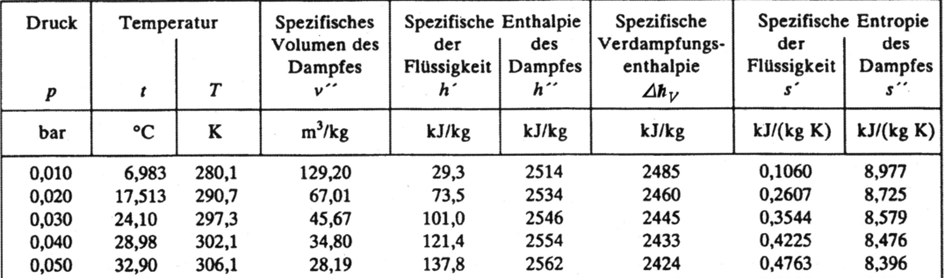

Die gemessene Lufttemperatur beträgt 293,15 K. Deshalb werden für die Interpolation die Werte $t_1$ = 290,7 K und $t_2$ = 297,3 K betrachtet.

$$p_D(t_0) = 0{,}020\,\text{bar} + \frac{293,15 - 290,7}{297,3 - 290,7} \cdot (0{,}030\,\text{bar} - 0{,}020\,\text{bar})$$

In [14]:
t0 = 293.15
t1 = 290.7
t2 = 297.3

p1 = 0.020
p2 = 0.030

p_D_bar = p1 + (t0 - t1) / (t2 - t1) * (p2 - p1)
p_D = p_D_bar * 10**5

print(f"Interpolierter Sättigungsdampfdruck p_D(t0) = {p_D:.2f} Pa")

Interpolierter Sättigungsdampfdruck p_D(t0) = 2371.21 Pa


Somit lässt sich die korrigierte Gaskonstante $R_\phi$ ermitteln

$$R_\phi = \frac{287,05}{1-\frac{0,377 \cdot 0,55 \cdot 2.371,21}{93.762,29}}$$

In [15]:
R_phi = 287.05 / (1 - (0.377 * 0.55 * 2371.21) / 93762.29)
print(f"R_phi = {R_phi:.2f} J/(kg·K)")

R_phi = 288.56 J/(kg·K)


Die aktuelle Luftdichte $\rho$ wird mit der umgeformten idealen Gasgleichung berechnet:
$$\rho = \frac {p_{umgebung}}{R_{S} \cdot t_0}$$

$$\rho = \frac{93.762{,}29\,\text{Pa}}{288{,}56\,\frac{J}{kg\,K} \cdot 293{,}15\,\text{K}}$$

In [16]:
rho = 93762.29 / (288.56 * 293.15)
print(f"rho = {rho:.3f} kg/m³")

rho = 1.108 kg/m³


Die Dynamische Viskosität $\eta$ wird durch die Sutherlandformel allgemein beschrieben:
$$\eta=\eta_0 \cdot \frac{T_0 + C}{T + C} \cdot \left(\frac{T}{T_0}\right)^{\frac{3}{2}}$$


Hierzu werden luftspezifische Konstanten und Referenztemperaturen benötigt:\
Sutherlandskonstante $C$ = 120 K\
Referenztemperatur $T_0$ = 291,15 K\
Referenzviskosität $\eta_0 = 18{,}27 \cdot 10^{-6}\,\text{Pa}\cdot\text{s}$

$$\eta = 18{,}27 \cdot 10^{-6}\,\text{Pa}\cdot\text{s}
\cdot \frac{291{,}15\,\text{K} + 120\,\text{K}}{293{,}15\,\text{K} + 120\,\text{K}}
\cdot \left(\frac{293{,}15\,\text{K}}{291{,}15\,\text{K}}\right)^{\frac{3}{2}}$$

In [17]:
eta = 18.27e-6 * (
    (291.15 + 120) / (293.15 + 120)
) * (
    (293.15 / 291.15) ** (3/2)
)

print(f"eta = {eta:.4e} Pa·s")

eta = 1.8369e-05 Pa·s


Alle Versuche werden bei einem konstanten Staudruck von $q_\infty =  400\,\text{Pa}$ gefahren.


$$q_\infty = \frac{\rho}{2}u_\infty^2$$

Somit kann die Anströmgeschwindigkeit $u_\infty$ bestimmt werden:
$$u_\infty = \sqrt{\frac{2 \cdot q_\infty}{\rho}}$$

$$u_\infty = \sqrt{\frac{2 \cdot 400\,\text{Pa}}{1{,}108\,\frac{kg}{m^3}}}$$

In [18]:
import math

u_inf = math.sqrt((2 * 400) / (1.108))

print(f"u_inf = {u_inf:.2f} m/s")

u_inf = 26.87 m/s


Die Reynoldszahl kann in diesem Versuch mithilfe der Flügeltiefe $c$ = 0,35 m bestimmt werden.
$$Re_c = \frac{\rho \cdot u_\infty \cdot c}{\eta}$$
$$Re_c = \frac{1{,}108\,\frac{kg}{m^3} \cdot 26{,}87\,\frac{m}{s} \cdot 0{,}35\,\text{m}}{1{,}8369 \cdot 10^{-5}\,\text{Pa}\cdot\text{s}}$$


In [19]:
Re_c = (1.108 * 26.87 * 0.35) / (1.8369e-5)
print(f"Re_c = {Re_c:.2e}")

Re_c = 5.67e+05


| Parameter | Wert |
|---|---|
| Ort | Hochschule München |
| Datum | 04.05.2026 |
| Uhrzeit | 10:00 bis 12:00 Uhr |
| Umgebungstemperatur | $t_0 = 20^\circ\text{C} \; (293{,}15\,\text{K})$ |
| Luftdruck | $p_\infty = 93\,762{,}29\,\text{Pa}$ |
| Relative Luftfeuchte | $\phi_L = 55\%$ |
| Luftdichte | $\rho = 1{,}108\,\mathrm{kg\,m^{-3}}$ |
| Dynamische Viskosität | $\eta = 1{,}8369 \cdot 10^{-5}\,\mathrm{Pa\,s}$ |
| Reynoldszahl | $Re_c = 5{,}67 \cdot 10^5$ |

# $c_p$-Verteilung für Anstell- und Klappenwinkel-Variationen

Die Auswertung des versuchtechnischen Praktikums "Hochauftriebssystem am Tragflügelprofil" erfolgt mithilfe eines Jupyter- Notebooks. Für die Ausführung des Codes werden dabei die folgenden Bibliotheken genutzt:

In [20]:
import math
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.integrate import trapezoid

Um den Verlauf des Druckbeiwerts $c_p$ zu verfolgen, wurden insgesamt über 67 Druckbohrungen auf dem Modell platziert. Alle diese Bohrungen sind über Schläuche mit einem Mehrkanalsystem verbunden, sodass die die Druckwerte der verschiedenen Messstellen zum Drucksensor geleitet werden. Die resultierenden Messungen werden über ein LabVIEW-System übertragen und als Excel-Datei gespeichert. 

## $c_p$-Verteilung für Anstellwinkel-Variation

Im Rahmen dieses Versuchs soll der $c_p$-Verlauf für unterschiedliche Anstellwinkelkonfigurationen ermittelt werden. Dabei wurden die Druckwerte bei Anstellwinkeln von $-5^\circ$ bis zur $25^\circ$ mit einer Differenz von 5 Grad gemessen $(\alpha=-5^\circ, 0^\circ, 5^\circ, 10^\circ, 15^\circ, 20^\circ, 25^\circ)$.
Die resultierenden Ergebnisse wurden in Excel-Dateien erfasst und können für die weitere Verarbeitung genutzt werden.

Der folgende Code besteht aus zwei Teilen. Der erste Teil wurde zum Einlesen der Excel-Daten genutzt. Mithilfe dieses Codes sollen die gemessenen Druckwerte für die jeweilige Anstellwinkel-Konfiguration an das Jupyter-Notebook übergeben werden. 
Im zweiten Teil des Codes wurde der $c_p$-Wert an jeweilige Bohrungsposition mithilfe der folgenden Formel bestimmt:
$$c_p(i) = \frac{p_i - p_\infty}{p_{\infty,\mathrm{dyn}}}$$
Die Drucksensoren erfassen die Differenz von statischem Druck $p_i$ an der Druckbohrung und statischem Druck in der Strömung $p_\infty$. Deshalb können diese Daten direkt aus den Excel-Dateien entnommen werden. Darüber hinaus werden alle Versuche bei einem konstanten Staudruck von 400 Pa gefahren. Es gilt $p_{\infty,\mathrm{dyn}} = 400\,\mathrm{Pa}$.

Nach der Ausführung dieses Codes wird eine Python-Liste erzeugt. In ersten Spalte der Liste ist die Koordinate der jeweiligen Bohrung als Verhältnis zwischen dem Abstand von der Nase $x$ und der Flügeltiefe $c$ ($\frac{x}{c}$) angegeben. In den nächsten Spalten sind die ermittelten $c_p$-Werte für unterschiedliche Anstellwinkel-Konfigurationen sichtbar. 

Es ist zu beachten, dass die Messpositionen FO10a, FO24, FO25, FU7a, FU13a, FU23, KO30 und KU31 nicht belegt sind, sodass an diesen Stellen keine Messdaten erfasst wurden. Darüber hinaus wurde nach Analyse der Druckwerte festgestellt, dass es auf der Position FO15 zu einer unerwarteten Änderung der Druckwerte kommt. So wurden beispielsweise auf den Positionen FO14 und FO16 die Drücke von -152,44 Pa bzw. -165,13 Pa gemessen, während der Druckwert auf der Position FO15 lediglich -2,30 Pa beträgt. Diese Abweichung kann durch Bohrungsverstopfung oder undichte Schlauchanschlüsse verursacht werden. 
Die Bestimmung des $c_p$-Wertes an den fehlenden sowie defekten Stellen erfolgt mithilfe der Methode der linearen Interpolation unter der Verwendung der Funktion $interpolate$.

Aufgrund der begrenzten Platzverhältnisse an der Kante des Flügelprofils war keine Bohrung möglich. Aus diesem Grund sollen die Daten ab KO30 extrapoliert werden.

In [25]:
# Teil 1
import pandas as pd

dateien = [
    "2024-05-06_11-48_alpha-5_eta-2_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha-5_eta-2_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-52_alpha0_eta-2_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-52_alpha0_eta-2_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-48_alpha5_eta-2_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha5_eta-2_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-52_alpha10_eta-2_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-52_alpha10_eta-2_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-52_alpha15_eta-2_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-52_alpha15_eta-2_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-52_alpha20_eta-2_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-52_alpha20_eta-2_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-52_alpha25_eta-2_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-52_alpha25_eta-2_Messdaten_Unterseite.xlsx"
]

p_inf = 93762.29
p_inf_dyn = 400

alle_results = []
#--------------------------------------------------------------------------------------------------------------------------------------
#Teil 2
import os

for file in dateien:
    df = pd.read_excel(file)

    df.columns = df.columns.str.replace("\n", " ").str.strip()

    druck_spalte = [c for c in df.columns if "Druck in Pa" in c][0]

    filename = os.path.basename(file)

    import re

    alpha = re.search(r"alpha(-?\d+)", filename).group(1)

    if "Ober" in filename:
        seite = "Oberseite"
    else:
        seite = "Unterseite"
    spaltenname = f"cp_alpha{alpha}_{seite}"

    # c_p berechnen
    df[spaltenname] = df[druck_spalte] / p_inf_dyn

    # x/c übernehmen
    if len(alle_results) == 0:
        alle_results.append(df[["x/c [-]"]])

    alle_results.append(df[[spaltenname]])

# zusammenführen
result_c_p_Anstellwinkel = pd.concat(alle_results, axis=1).round(2)

# Interpolation
result_c_p_Anstellwinkel = result_c_p_Anstellwinkel.interpolate()

print(result_c_p_Anstellwinkel.to_string())

    x/c [-]  cp_alpha-5_Oberseite  cp_alpha-5_Unterseite  cp_alpha0_Oberseite  cp_alpha0_Unterseite  cp_alpha5_Oberseite  cp_alpha5_Unterseite  cp_alpha10_Oberseite  cp_alpha10_Unterseite  cp_alpha15_Oberseite  cp_alpha15_Unterseite  cp_alpha20_Oberseite  cp_alpha20_Unterseite  cp_alpha25_Oberseite  cp_alpha25_Unterseite
0      0.00                 0.490                 -1.080                0.940                -0.330                0.990                 0.120                 0.710                  0.590                -0.020                  0.890                -0.910                  1.000                 0.210                  0.980
1      0.01                 0.940                 -0.880                0.550                -0.340                0.050                -0.000                -0.890                  0.390                -2.100                  0.690                -3.160                  0.860                -0.450                  0.840
2      0.03                 0.4

### Plot der $c_p$-Kurven für die Anstellwinkel-Variation

Nachdem der Wert $c_p$ für die jeweilige Messposition ermittelt wurde, kann die Verteilung des Druckbeiwerts für unterschiedliche Anstellkonfigurationen in einem Diagramm dargestellt werden.

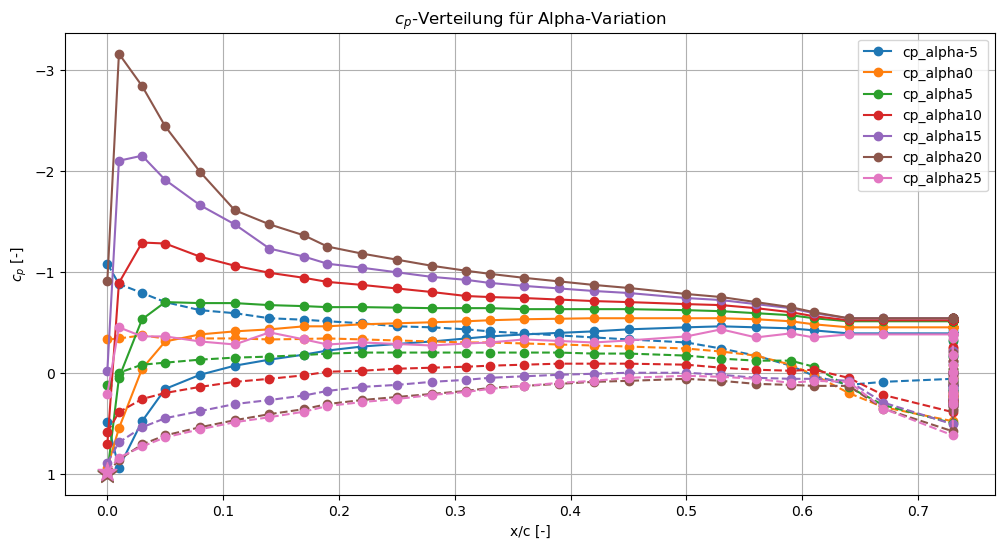

In [24]:
import matplotlib.pyplot as plt
import re

plt.figure(figsize=(12,6))

x = result_c_p_Anstellwinkel["x/c [-]"]

alpha_colors = {}
alpha_plotted = {}  

color_cycle = plt.cm.tab10.colors
color_index = 0

for col in result_c_p_Anstellwinkel.columns:
    if "cp_" not in col:
        continue

    alpha = re.search(r"alpha(-?\d+)", col).group(1)

    seite = "Ober" if "Oberseite" in col else "Unter"

    if alpha not in alpha_colors:
        alpha_colors[alpha] = color_cycle[color_index % len(color_cycle)]
        color_index += 1

    color = alpha_colors[alpha]
    linestyle = "-" if seite == "Ober" else "--"

    label = f"cp_alpha{alpha}" if alpha not in alpha_plotted else None
    alpha_plotted[alpha] = True

    plt.plot(
        x,
        result_c_p_Anstellwinkel[col],
        marker='o',
        linestyle=linestyle,
        color=color,
        label=label
    )
    
    mask = result_c_p_Anstellwinkel[col] >= 0.95

    plt.scatter(
        x[mask],
        result_c_p_Anstellwinkel[col][mask],
        marker='*',
        color=color,
        s=200,
        zorder=5
    )

plt.xlabel("x/c [-]")
plt.ylabel("$c_p$ [-]")
plt.gca().invert_yaxis()
plt.grid(True)
plt.legend()
plt.title("$c_p$-Verteilung für Alpha-Variation")

plt.show()

### Analyse der Staupunktpositionen für die Anstellwinkelkonfiguration

Aus dem Diagrammverlauf ist es deutlich zu erkennen, dass sich die Staupunkte am vorderen Rand des Profils befinden. Bei einem Staupunkt wird die Luftströmung sich auf zwei Strömungen aufteilt. 

Der erste Staupunkt kann bei einem Anstellwinkel von $\alpha=5^\circ$ auf der Flügeloberseite an der Stelle FO1 beobachtet werden. Dieser Staupunkt befindet sich am nächsten zur Nasenspitze und kann dadurch erklärt werden, dass die Strömung aufgrund des relativ kleinen Anstellwinkels direkt an der Vorderkante des Profils eintrifft. Die weiteren Staupunkten entstehen bei den Anstellwinkeln von $\alpha=20^\circ$ und $\alpha=25^\circ$. Im Unterschied zum ersten Staupunkt wird der Druckbeiwert $c_p=0$ nicht an der Flügeloberseite, sondern an der Unterseite des Profils erreicht. Der Grund dafür ist, dass sich der Staupunkt mit zunehmendem Anstellwinkel zur Profilunterseite verschiebt. Dies entsteht infolge der asymmetrischen Umlenkung der Strömung um das Profil. Dadurch beschleunigt die Strömung auf der Oberseite stärker, während sich auf der Unterseite höhere Drücke ausbilden. 

### $c_p$-Verteilung für Klappenwinkel-Variation

In [10]:
import pandas as pd

dateien = [
    "2024-05-06_11-48_alpha5_eta-2_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha5_eta-2_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-48_alpha5_eta0_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha5_eta0_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-48_alpha5_eta5_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha5_eta5_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-48_alpha5_eta10_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha5_eta10_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-48_alpha5_eta15_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha5_eta15_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-48_alpha5_eta20_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha5_eta20_Messdaten_Unterseite.xlsx",
    "2024-05-06_11-48_alpha5_eta25_Messdaten_Oberseite.xlsx",
    "2024-05-06_11-48_alpha5_eta25_Messdaten_Unterseite.xlsx"
]

p_inf = 93762.29
p_inf_dyn = 400

alle_results = []
#--------------------------------------------------------------------------------------------------------------------------------------
#Teil 2
import os

for file in dateien:
    df = pd.read_excel(file)

    df.columns = df.columns.str.replace("\n", " ").str.strip()

    druck_spalte = [c for c in df.columns if "Druck in Pa" in c][0]

    filename = os.path.basename(file)

    import re

    eta = re.search(r"eta(-?\d+)", filename).group(1)

    if "Ober" in filename:
        seite = "Oberseite"
    else:
        seite = "Unterseite"
    spaltenname = f"cp_eta{eta}_{seite}"

    # c_p berechnen
    df[spaltenname] = df[druck_spalte] / p_inf_dyn

    # x/c übernehmen
    if len(alle_results) == 0:
        alle_results.append(df[["x/c [-]"]])

    alle_results.append(df[[spaltenname]])

# zusammenführen
result_c_p_Klappenwinkel = pd.concat(alle_results, axis=1).round(2)

# Interpolation
result_c_p_Klappenwinkel = result_c_p_Klappenwinkel.interpolate()

print(result_c_p_Klappenwinkel.to_string())

    x/c [-]  cp_eta-2_Oberseite  cp_eta-2_Unterseite  cp_eta0_Oberseite  cp_eta0_Unterseite  cp_eta5_Oberseite  cp_eta5_Unterseite  cp_eta10_Oberseite  cp_eta10_Unterseite  cp_eta15_Oberseite  cp_eta15_Unterseite  cp_eta20_Oberseite  cp_eta20_Unterseite  cp_eta25_Oberseite  cp_eta25_Unterseite
0      0.00               0.990                0.120              0.980               0.200               0.98               0.220               0.970                0.240                0.96                0.260                0.97                0.280               0.970                0.290
1      0.01               0.050               -0.000             -0.050               0.060              -0.08               0.080              -0.110                0.100               -0.14                0.120               -0.15                0.130              -0.170                0.150
2      0.03              -0.530               -0.080             -0.600              -0.030              -0.63     

### Plot der $c_p$-Kurven für die Klappenwinkel-Variation

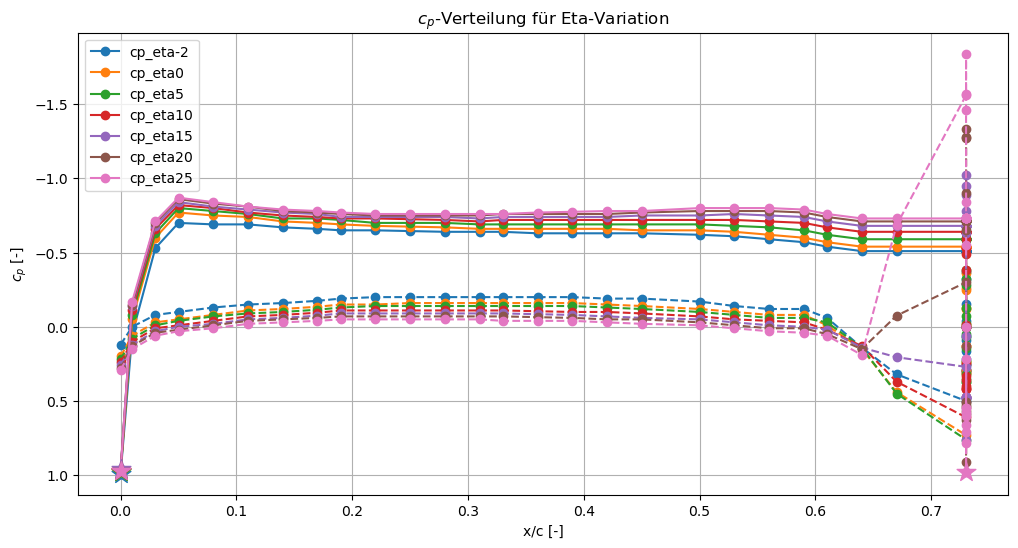

In [11]:
import matplotlib.pyplot as plt
import re

plt.figure(figsize=(12,6))

x = result_c_p_Klappenwinkel["x/c [-]"]

eta_colors = {}
eta_plotted = {}  

color_cycle = plt.cm.tab10.colors
color_index = 0

for col in result_c_p_Klappenwinkel.columns:
    if "cp_" not in col:
        continue

    eta = re.search(r"eta(-?\d+)", col).group(1)

    seite = "Ober" if "Oberseite" in col else "Unter"

    if eta not in eta_colors:
        eta_colors[eta] = color_cycle[color_index % len(color_cycle)]
        color_index += 1

    color = eta_colors[eta]
    linestyle = "-" if seite == "Ober" else "--"

    label = f"cp_eta{eta}" if eta not in eta_plotted else None
    eta_plotted[eta] = True

    plt.plot(
        x,
        result_c_p_Klappenwinkel[col],
        marker='o',
        linestyle=linestyle,
        color=color,
        label=label
    )
    
    mask = result_c_p_Klappenwinkel[col] >= 0.95

    plt.scatter(
        x[mask],
        result_c_p_Klappenwinkel[col][mask],
        marker='*',
        color=color,
        s=200,
        zorder=5
    )

plt.xlabel("x/c [-]")
plt.ylabel("$c_p$ [-]")
plt.gca().invert_yaxis()
plt.grid(True)
plt.legend()
plt.title("$c_p$-Verteilung für Eta-Variation")

plt.show()

### Analyse der Staupunktpositionen für die Klappenwinkelkonfiguration

Nach Analyse des Diagramms für Klappenwinkelkonfiguration kann festgestellt werden, dass sich der Staupunkt auch hier am vorderen Rand des Profils bei $\eta=-2^\circ$, $\eta=5^\circ$, $\eta=20^\circ$ und $\eta=25^\circ$ befindet. Außerdem aufgrund des veränderten Anstellwinkels bei einem Klappenwinkel $\eta=25^\circ$ kann sich der Staupunkt leicht verschieben, würde aber in der Nähe des vorderen Randes bleiben. Aus dem Diagramm ist es auch zu bemerken, dass der Wert $c_p=1$ bei einem Klappenwinkel von $\eta=25^\circ$ auf einer Position von $x/c=0,73$ erreicht wurde. Allerdings ist es schwierig, die Genauigkeit dieser Aussage abzuschätzen, weil die Druckwerte für diese Position durch lineare Interpolation ermittelt wurden. 

"""
## 3.2 Berechnung des Kraftbeiwerts $c_N$ und der Normalkraft $N'$
 
Der Kraftbeiwert $c_N$ wird durch numerische Integration der $c_p$-Verteilung 
über die normierte Profiltiefe $x/c$ berechnet:
 
$$c_N = \int_0^1 \left( c_{p,\text{unten}} - c_{p,\text{oben}} \right) \, d\left(\frac{x}{c}\right)$$
 
Die $c_p$-Werte ergeben sich direkt aus den gemessenen Differenzdrücken:
 
$$c_p(i) = \frac{p_i - p_\infty}{p_{\infty,\text{dyn}}} = \frac{\Delta p_i}{q_\infty}$$
 
Da die Drucksensoren bereits Differenzdrücke $p_i - p_\infty$ liefern, gilt:
$$c_p(i) = \frac{\text{Messwert [Pa]}}{q_\infty}$$
 
Gemäß den Hinweisen der Versuchsbeschreibung werden folgende Ergänzungen vorgenommen:
1. Der erste Messpunkt der Unterseite (FU1) wird auf den Wert der Oberseite (FO1) gesetzt.
2. Im Spalt zwischen Flügel und Klappe wird der Druckverlauf linear interpoliert.
3. An der Hinterkante der Klappe wird $c_p = 0$ angenommen.
 
Die Normalkraft pro Tiefeneinheit $N'$ ergibt sich zu:
$$N' = c_N \cdot q_\infty \cdot c$$
 
mit der Profiltiefe $c$ und dem Staudruck $q_\infty = 400\,\text{Pa}$.
"""

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
 
folder_path = r""   # leer = Notebook-Ordner
p_dyn_ref   = 400   # Pa
c_profil    = 0.35  # m (Versuchsbeschreibung Seite 13)

In [39]:
def lese_druckdaten(filepath):
    df = pd.read_excel(filepath)
    df.columns = df.columns.str.replace("\n", " ").str.strip()

    bohrung_col = [c for c in df.columns if 'Bohrung' in c or 'Nummer' in c][0]
    druck_col   = [c for c in df.columns if 'Druck in Pa' in c][0]
    xc_col      = [c for c in df.columns if 'x/c' in c][0]

    df[bohrung_col] = df[bohrung_col].astype(str).str.strip()

    result = {}
    for typ in ['FO', 'FU', 'KO', 'KU']:
        mask = df[bohrung_col].str.startswith(typ)
        if mask.any():
            xc    = df.loc[mask, xc_col].values.astype(float)
            druck = df.loc[mask, druck_col].values.astype(float)

            # NaN-Werte linear interpolieren (defekte Kanäle)
            nan_mask = np.isnan(druck)
            if nan_mask.any():
                druck[nan_mask] = np.interp(xc[nan_mask], xc[~nan_mask], druck[~nan_mask])

            result[typ] = {'xc': xc, 'druck': druck}
    return result
 
 
def berechne_cN(daten_ober, daten_unter, p_dyn):
    """
    Oberseite (Saugseite):  FO  (aus Oberseite-Datei) + KO (aus Unterseite-Datei)
    Unterseite (Druckseite): FU (aus Unterseite-Datei) + KU (aus Unterseite-Datei)
    """
    # cp berechnen
    cp_FO = daten_ober['FO']['druck']   / p_dyn
    cp_KO = daten_unter['KO']['druck']  / p_dyn   # <-- war daten_ober, jetzt daten_unter
    cp_FU = daten_unter['FU']['druck']  / p_dyn
    cp_KU = daten_unter['KU']['druck']  / p_dyn

    x_FO = daten_ober['FO']['xc']
    x_KO = daten_unter['KO']['xc']     # <-- war daten_ober, jetzt daten_unter
    x_FU = daten_unter['FU']['xc']
    x_KU = daten_unter['KU']['xc']

    # Ergänzung 1: FU1 = FO1
    cp_FU[0] = cp_FO[0]

    # Oberseite zusammensetzen & sortieren (FO + KO)
    x_o  = np.concatenate([x_FO,  x_KO])
    cp_o = np.concatenate([cp_FO, cp_KO])
    idx  = np.argsort(x_o)
    x_o, cp_o = x_o[idx], cp_o[idx]

    # Unterseite zusammensetzen & sortieren (FU + KU)
    x_u  = np.concatenate([x_FU,  x_KU])
    cp_u = np.concatenate([cp_FU, cp_KU])
    idx  = np.argsort(x_u)
    x_u, cp_u = x_u[idx], cp_u[idx]

    # Ergänzung 2: cp = 0 an Hinterkante
    x_end = max(x_o[-1], x_u[-1])
    if x_o[-1] < x_end:
        x_o  = np.append(x_o,  x_end);  cp_o = np.append(cp_o, 0.0)
    if x_u[-1] < x_end:
        x_u  = np.append(x_u,  x_end);  cp_u = np.append(cp_u, 0.0)

    # Integration
    cN = trapezoid(cp_u, x_u) - trapezoid(cp_o, x_o)
    return cN

In [40]:
alpha_var = [-5, 0, 5, 10, 15, 20, 25]
 
dateien_alpha = [
    ['2024-05-06_11-48_alpha-5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha-5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha0_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha0_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha10_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha10_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha15_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha15_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha20_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha20_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha25_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha25_eta-2_Messdaten_Unterseite.xlsx'],
]
 
cN_alpha     = []
N_prim_alpha = []
 
for i, alpha in enumerate(alpha_var):
    d_ober  = lese_druckdaten(os.path.join(folder_path, dateien_alpha[i][0]))
    d_unter = lese_druckdaten(os.path.join(folder_path, dateien_alpha[i][1]))
    cN      = berechne_cN(d_ober, d_unter, p_dyn_ref)
    N_prim  = cN * p_dyn_ref * c_profil
    cN_alpha.append(cN)
    N_prim_alpha.append(N_prim)
    print(f"alpha = {alpha:+3d}°  →  c_N = {cN:.4f},   N' = {N_prim:.2f} N/m")

alpha =  -5°  →  c_N = -0.1009,   N' = -14.12 N/m
alpha =  +0°  →  c_N = 0.1103,   N' = 15.45 N/m
alpha =  +5°  →  c_N = 0.3024,   N' = 42.34 N/m
alpha = +10°  →  c_N = 0.5496,   N' = 76.94 N/m
alpha = +15°  →  c_N = 0.7801,   N' = 109.21 N/m
alpha = +20°  →  c_N = 0.9421,   N' = 131.89 N/m
alpha = +25°  →  c_N = 0.3971,   N' = 55.60 N/m


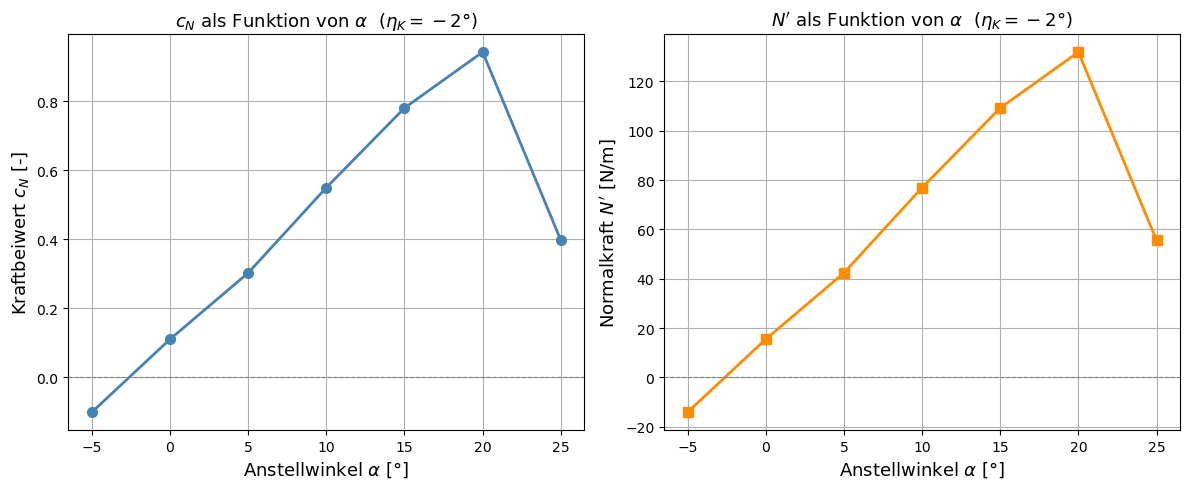

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].plot(alpha_var, cN_alpha, 'o-', color='steelblue', lw=2, ms=7)
axes[0].set_xlabel(r'Anstellwinkel $\alpha$ [°]', fontsize=13)
axes[0].set_ylabel(r'Kraftbeiwert $c_N$ [-]', fontsize=13)
axes[0].set_title(r'$c_N$ als Funktion von $\alpha$  ($\eta_K = -2°$)', fontsize=13)
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].grid(True)
 
axes[1].plot(alpha_var, N_prim_alpha, 's-', color='darkorange', lw=2, ms=7)
axes[1].set_xlabel(r'Anstellwinkel $\alpha$ [°]', fontsize=13)
axes[1].set_ylabel(r"Normalkraft $N'$ [N/m]", fontsize=13)
axes[1].set_title(r"$N'$ als Funktion von $\alpha$  ($\eta_K = -2°$)", fontsize=13)
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].grid(True)
 
plt.tight_layout()
plt.show()

In [42]:
eta_var = [-2, 0, 5, 10, 15, 20, 25]
 
dateien_eta = [
    ['2024-05-06_11-48_alpha5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta0_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta0_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta5_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta5_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta10_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta10_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta15_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta15_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta20_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta20_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta25_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta25_Messdaten_Unterseite.xlsx'],
]
 
cN_eta     = []
N_prim_eta = []
 
for i, eta in enumerate(eta_var):
    d_ober  = lese_druckdaten(os.path.join(folder_path, dateien_eta[i][0]))
    d_unter = lese_druckdaten(os.path.join(folder_path, dateien_eta[i][1]))
    cN      = berechne_cN(d_ober, d_unter, p_dyn_ref)
    N_prim  = cN * p_dyn_ref * c_profil
    cN_eta.append(cN)
    N_prim_eta.append(N_prim)
    print(f"eta_K = {eta:+3d}°  →  c_N = {cN:.4f},   N' = {N_prim:.2f} N/m")

eta_K =  -2°  →  c_N = 0.3024,   N' = 42.34 N/m
eta_K =  +0°  →  c_N = 0.3849,   N' = 53.89 N/m
eta_K =  +5°  →  c_N = 0.5019,   N' = 70.27 N/m
eta_K = +10°  →  c_N = 0.6303,   N' = 88.24 N/m
eta_K = +15°  →  c_N = 0.7496,   N' = 104.95 N/m
eta_K = +20°  →  c_N = 0.8449,   N' = 118.28 N/m
eta_K = +25°  →  c_N = 0.9389,   N' = 131.45 N/m


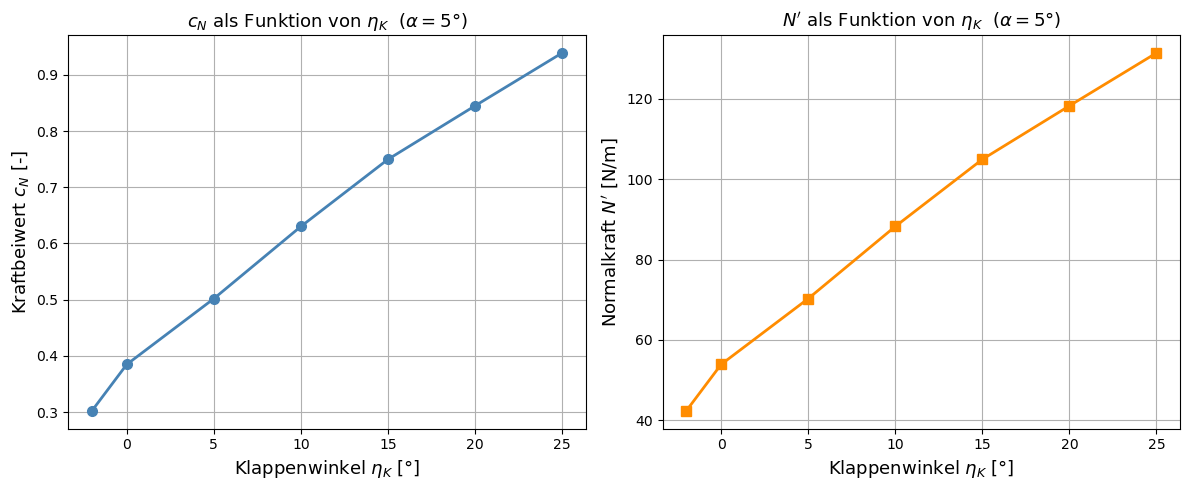

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].plot(eta_var, cN_eta, 'o-', color='steelblue', lw=2, ms=7)
axes[0].set_xlabel(r'Klappenwinkel $\eta_K$ [°]', fontsize=13)
axes[0].set_ylabel(r'Kraftbeiwert $c_N$ [-]', fontsize=13)
axes[0].set_title(r'$c_N$ als Funktion von $\eta_K$  ($\alpha = 5°$)', fontsize=13)
axes[0].grid(True)
 
axes[1].plot(eta_var, N_prim_eta, 's-', color='darkorange', lw=2, ms=7)
axes[1].set_xlabel(r'Klappenwinkel $\eta_K$ [°]', fontsize=13)
axes[1].set_ylabel(r"Normalkraft $N'$ [N/m]", fontsize=13)
axes[1].set_title(r"$N'$ als Funktion von $\eta_K$  ($\alpha = 5°$)", fontsize=13)
axes[1].grid(True)
 
plt.tight_layout()
plt.show()